# Hard Rock: resultados após a conferência dos 20 candidatos

17 gravações-base incluídas por relato de escuta do autor: sete no grupo menor e dez no maior. HR02 e HR10 excluídos por extensão musical de encerramento; HR03 por correspondência do ID congelado não suficientemente confirmada e alternativa ausente das fontes. Não houve escuta pelo assistente nem confirmação de identidade digital de master.

[Protocolo e adjudicação](../docs/workshop-protocolo.md) · [Relatos](../docs/conferencia-hard-rock.md) · [Resultados e limites](../docs/resultados-hard-rock.md)

Fontes já baixadas, com hashes de `data/source-manifest.json`; este caderno não faz consultas à rede nem altera o corte. Requer `requirements-workshop.txt`.

In [1]:
from pathlib import Path
import csv, hashlib, json, statistics, subprocess, sys
from collections import Counter
ROOT = Path.cwd().resolve()
if not (ROOT / "scripts").exists(): ROOT = ROOT.parent
sys.path.insert(0,str(ROOT / "scripts"))
from analyze_workshop import read_review
from prepare_workshop import load_sources
lock,review,lock_hash=read_review(ROOT)
evidence=json.loads((ROOT / "data/workshop/recording-review-evidence.json").read_text())
assert evidence["selection_lock_sha256"]==lock_hash
assert evidence["assistant_audio_reviews"]==0
assert evidence["review_csv_sha256"]==hashlib.sha256((ROOT / "data/workshop/recording-review.csv").read_bytes()).hexdigest()
assert {r["candidate_id"] for r in evidence["records"]}=={r["candidate_id"] for r in review}
print("Lock:",lock_hash)
print("Revisão de todos os candidatos:",dict(Counter(r["decision"] for r in review)))
print("Corte preservado:",lock["audience_cutoff_views"])


Lock: d69e21e986e05dbe8fff536cb7b8d64a71ba3a877c5a7c9efb78a5a4e649e304
Revisão de todos os candidatos: {'include': 17, 'exclude': 3}
Corte preservado: 89776313.5


In [2]:
# Reproduzir a análise principal somente com decisões atribuídas e finais.
run=subprocess.run([sys.executable,str(ROOT / "scripts/analyze_workshop.py"),"--root",str(ROOT)],cwd=ROOT,capture_output=True,text=True)
if run.returncode: raise RuntimeError(run.stderr or run.stdout)
summary=json.loads((ROOT / "data/processed/hard-rock-validated-summary.json").read_text())
public=json.loads((ROOT / "data/workshop/analysis-summary.json").read_text())
assert summary==public
assert summary["not_a_main_result"] is False
print(json.dumps(summary["flow"],ensure_ascii=False,indent=2))
print("Software:",summary["software"])


{
  "candidates": 20,
  "decisions": {
    "include": 17,
    "exclude": 3
  },
  "review_exclusions": [
    {
      "candidate_id": "HR02",
      "reason": "musical_tail_extension_in_spotify"
    },
    {
      "candidate_id": "HR03",
      "reason": "frozen_recording_not_confirmed_alternative_absent_from_both_snapshots"
    },
    {
      "candidate_id": "HR10",
      "reason": "musical_tail_extension_in_spotify"
    }
  ],
  "feature_exclusions": [],
  "plotted": 17,
  "group_counts": {
    "lower": 7,
    "higher": 10
  }
}
Software: {'python': '3.12.14', 'numpy': '2.3.5', 'matplotlib': '3.10.8'}


## Auditoria independente dos valores e perdas

Descritores da edição Spotify, não do áudio integral do clipe. Energy é intensidade/atividade perceptual; danceability estima adequação à dança; acousticness é confiança de que a faixa é acústica. As três escalas são [0,1], conforme [Spotify](https://developer.spotify.com/documentation/web-api/reference/get-audio-features).

Não confundir intervalos interquartis com intervalos de confiança. Quantis por interpolação linear; sem teste de significância. As três perdas estão no grupo menor; os grupos não foram reequilibrados.

In [3]:
manifest,_,_,_=load_sources(ROOT)
source=next(s for s in manifest["sources"] if s["name"]=="Spotify and Youtube")
with (ROOT / source["local_path"]).open(newline="",encoding="utf-8-sig") as f:
    source_rows=list(csv.DictReader(f))
selected=[r for r in review if r["decision"]=="include"]
data={r["Uri"].removeprefix("spotify:track:"):r for r in source_rows if r["Uri"].removeprefix("spotify:track:") in {r["track_id"] for r in selected}}
assert len(selected)==len(data)==17
assert len({r["artist"] for r in selected})==17
assert all(r["track_id"] in {c["track_id"] for c in lock["candidates"]} for r in selected)
for feature in summary["features"]:
    for group in ["lower","higher"]:
        values=[float(data[r["track_id"]][feature]) for r in selected if r["audience_group"]==group]
        s=summary["summaries"][feature][group]
        assert statistics.median(values)==s["median"]
        assert min(values)==s["min"] and max(values)==s["max"]
        assert all(0<=v<=1 for v in values)
        print(feature,group,"n",s["n"],"mediana",s["median"],"IIQ",[s["q1"],s["q3"]],"amplitude",[s["min"],s["max"]])
    a,b=summary["summaries"][feature]["lower"],summary["summaries"][feature]["higher"]
    assert max(a["min"],b["min"])<=min(a["max"],b["max"])
print("Intervalos individuais se sobrepõem nos três descritores.")


Energy lower n 7 mediana 0.931 IIQ [0.895, 0.9675] amplitude [0.722, 0.982]
Energy higher n 10 mediana 0.7545 IIQ [0.70075, 0.83] amplitude [0.452, 0.98]
Danceability lower n 7 mediana 0.54 IIQ [0.3355, 0.573] amplitude [0.303, 0.679]
Danceability higher n 10 mediana 0.35050000000000003 IIQ [0.271, 0.49525] amplitude [0.202, 0.63]
Acousticness lower n 7 mediana 0.0202 IIQ [0.00908, 0.0474] amplitude [0.00253, 0.435]
Acousticness higher n 10 mediana 0.02595 IIQ [0.012674999999999999, 0.110725] amplitude [0.00322, 0.638]
Intervalos individuais se sobrepõem nos três descritores.


In [4]:
# Nenhum descritor será transferido para a alternativa sugerida em HR03.
alt="3pIU81Fd7sTMdaaZ5GI9Vj"
assert not any(r["Uri"]=="spotify:track:"+alt for r in source_rows)
genre_source=next(s for s in manifest["sources"] if s["name"]=="Spotify Tracks Dataset")
with (ROOT / genre_source["local_path"]).open(newline="",encoding="utf-8-sig") as f:
    assert not any(r["track_id"]==alt for r in csv.DictReader(f))
observation=json.loads((ROOT / "data/workshop/hr03-alternative-observation.json").read_text())
assert observation["facts"]["og:url"].endswith(alt)
print("HR03 alternativa ausente dos snapshots; data de catálogo:",observation["facts"]["music:release_date"])
print("Contexto:",json.dumps(summary["context"],ensure_ascii=False,indent=2))


HR03 alternativa ausente dos snapshots; data de catálogo: 2005-01-01
Contexto: {
  "lower": {
    "n": 7,
    "distinct_artists": 7,
    "catalogue_year_min": 1980,
    "catalogue_year_median": 1984,
    "catalogue_year_max": 1988,
    "video_publication_available": 0,
    "video_age_years_median": null,
    "formats": {
      "unknown": 3,
      "music_video": 4
    }
  },
  "higher": {
    "n": 10,
    "distinct_artists": 10,
    "catalogue_year_min": 1980,
    "catalogue_year_median": 1984.0,
    "catalogue_year_max": 1989,
    "video_publication_available": 0,
    "video_age_years_median": null,
    "formats": {
      "unknown": 9,
      "music_video": 1
    }
  }
}


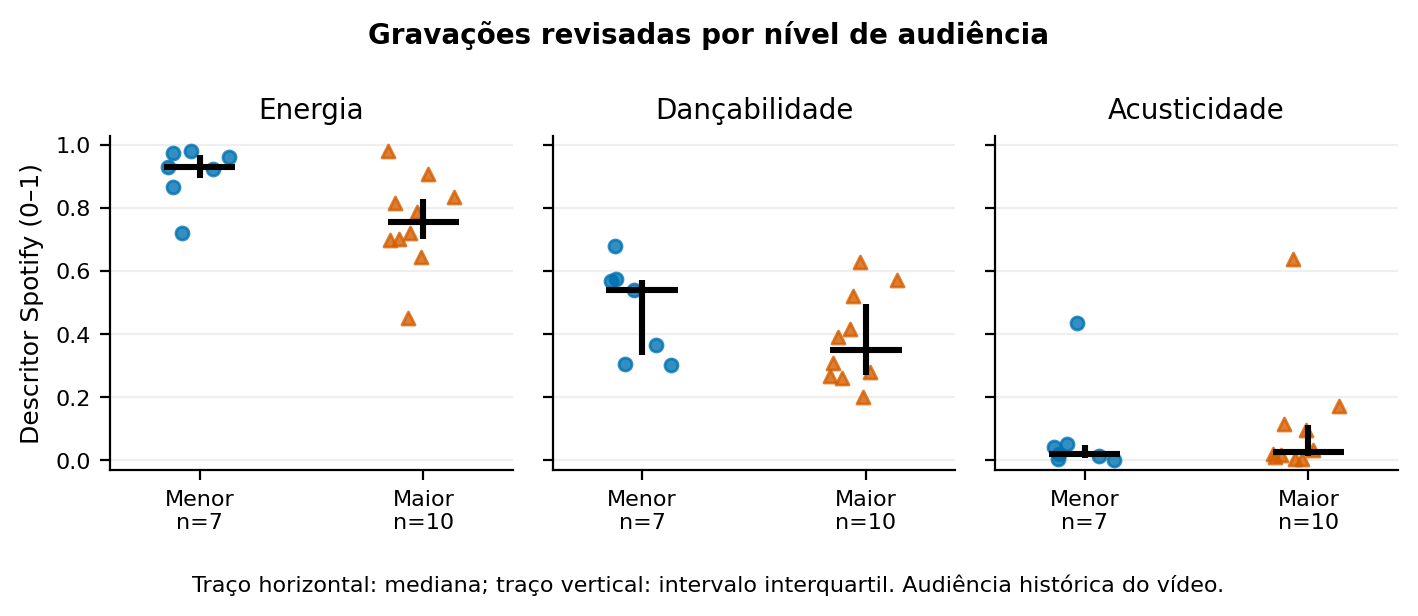

In [5]:
import matplotlib.pyplot as plt
fig,ax=plt.subplots(figsize=(12,4.5))
ax.imshow(plt.imread(ROOT / "figures/hard-rock-validated.png"))
ax.axis("off")
plt.tight_layout()
plt.show()


## Interpretação delimitada

Na seleção curada, o grupo de maior audiência tem menores medianas de energy (0,7545 versus 0,9310) e danceability (0,3505 versus 0,5400). As medianas de acousticness são próximas (0,02595 versus 0,02020), sem demonstração de equivalência. A dispersão e os pontos mostram heterogeneidade.

Todas as perdas ocorreram no grupo menor, podendo alterar seu perfil. Datas de publicação disponíveis: 0/17; formatos desconhecidos: 12/17. Uma faixa por artista reduz repetição, mas não elimina diferenças entre artistas, subestilos ou exposição. Datas de catálogo não foram comprovadas como primeiros lançamentos. A população é uma interseção de fontes, não o gênero inteiro.

Hipótese futura pós-hoc e não confirmada nesta exploração: ver [registro de achados](../docs/hipoteses.md). A comparação não determina causa do sucesso, capacidade preditiva ou uma regra geral para música.